# Sin-Stocks — a quantitative teardown
### Neglect premium · daily total return · HAC inference · OLS decomposition · bootstrap CI

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Neglect_premium: Mixed](https://img.shields.io/badge/Neglect_premium%3F-Mixed-8b949e?style=flat-square)

The quantitative companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb). We test the Hong & Kacperczyk (2009) neglect premium on a 2008–2026 daily total-return tape: equal-weight sin basket (MO, PM, STZ, LVS, LMT, RTX) vs SPY and DSI. Inference: HAC Newey-West t-stat, block-bootstrap Sharpe CI, OLS alpha/beta vs both benchmarks, crash-episode analysis, sub-period breakdown, and a synthetic positive control.

> ⚠️ **Not investment advice.** Reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from sin_stocks import data, strategy as st

CACHE = os.path.abspath(os.path.join("..", "_cache"))
ALL_TICKERS = data.ALL_TICKERS

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE)) for t in ALL_TICKERS)

HAVE_REAL = _have_cache()
print("real price cache present:", HAVE_REAL)

# Frozen results (mirror of docs/results.md)
R = dict(
    n=4589, start="2008-03-18", end="2026-06-12",
    sin_cagr=10.60, sin_vol=20.9, sin_sharpe=0.481, sin_maxdd=-65.9,
    sin_t=2.06, sin_total_ret=527,
    spy_cagr=12.17, spy_vol=19.8, spy_sharpe=0.579, spy_maxdd=-51.5,
    spy_t=2.82, spy_total_ret=710,
    dsi_cagr=12.11, dsi_vol=19.8, dsi_sharpe=0.577, dsi_maxdd=-49.9,
    dsi_t=2.80, dsi_total_ret=702,
    excess_bps=-0.558, excess_cagr=-1.40, excess_t=-0.46,
    excess_sharpe_ci_lo=-0.539, excess_sharpe_ci_hi=0.339, excess_frac_neg=68,
    ols_alpha_bps=0.242, ols_alpha_ann=0.61, ols_t_alpha=0.20,
    ols_beta=0.8245, ols_r2=0.6088,
    ols_dsi_alpha_bps=0.444, ols_dsi_alpha_ann=1.13, ols_dsi_t_alpha=0.34, ols_dsi_beta=0.7838,
    mo_cagr=13.64, mo_sharpe=0.59, pm_cagr=12.57, pm_sharpe=0.50,
    stz_cagr=13.35, stz_sharpe=0.42,
    lvs_cagr=0.62, lvs_sharpe=0.01, lvs_maxdd=-98.3, lvs_vol=58.5,
    lmt_cagr=13.09, lmt_sharpe=0.52, rtx_cagr=10.95, rtx_sharpe=0.39,
    c08_prot=11.7, c11_prot=4.3, c15_prot=10.9,
    c18a_prot=-13.6, c18b_prot=-0.9, c20_prot=-19.4, c22_prot=-8.3, c25_prot=-7.7,
)

from quantlab import analytics, stats


real price cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Excess return **-1.40%/yr**, HAC *t* = **-0.46**; bootstrap excess-Sharpe CI [-0.539, +0.339] (68% of resamples negative). OLS alpha **+0.61%/yr**, *t* = **+0.20**. |
| **Tradability** | `MIRAGE` | SIN_EW CAGR +10.60% vs SPY +12.17%; Sharpe 0.481 vs 0.579. LVS max drawdown -98.3% wrecks the basket. |
| **Neglect premium?** | `MIXED` | Outperformed 2009–2017 (value era), failed 2018–2021 (growth era). Regime-dependent, not durable. |

> The basket earns a positive raw t-stat (t = +2.06), confirming equity exposure. But the *excess return* t = −0.46 confirms there is no neglect premium over the market in this post-publication sample.

## 1 · The claim, steelmanned

Let $r_{S,t}$, $r_{B,t}$ be the daily log total-returns of SIN_EW and SPY. The neglect premium hypothesis asserts:

- **H₁ (neglect premium).** $\mathbb{E}[r_{S,t} - r_{B,t}] > 0$ — positive mean excess return, robust to autocorrelation (HAC t ≥ 2).
- **H₂ (market-neutral alpha).** Positive OLS alpha: $r_{S,t} = \alpha + \beta r_{B,t} + \epsilon_t$ with $\alpha > 0$ at *t* ≥ 2. Beta < 1 (sector/defensive tilt) without positive alpha is just a different factor loading, not a neglect premium.
- **H₃ (ESG counter-portfolio underperforms).** DSI returns < sin returns. The ESG exclusion should depress DSI and boost sin.

We fail to confirm H₁, H₂, and H₃ on the 2008–2026 tape at any conventional significance level.

## 2 · So what?

**H₁** is the economic core of Hong & Kacperczyk (2009) — the entire 'vice pays' narrative.  If H₁ fails post-2009, either the premium was arbitraged away by unconstrained capital after publication, or it was a specific-period effect tied to the value factor dominance of the 1965–2006 sample.  **H₂** tests whether what excess return exists is market-neutral (genuine neglect) or is just a value/sector tilt.  Beta = 0.825 confirms the sector tilt; alpha t = +0.20 confirms zero market-neutral effect.  **H₃** is the mirror claim: DSI (the socially responsible counter-portfolio) should underperform.  In fact DSI returned 702% vs sin's 527% — the opposite of the prediction.

## 3 · How we'd know — the protocol

- **Data.** Yahoo Finance daily adjusted total-return closes (`auto_adjust=True`) for MO, PM, STZ, LVS, LMT, RTX (sin basket), SPY, and DSI, aligned on inner join. Start: 2008-03-18 (PM IPO date); end: 2026-06-12; n = 4,589 daily observations.
- **Basket construction.** Equal-weight across six tickers, daily.  A deterministic synthetic tape with a tunable planted alpha serves as the positive control — confirms the engine can detect edge when it exists.
- **Return test.** Daily log-return series; HAC Newey-West t-stat on the mean excess return; block-bootstrap 95% CI on excess Sharpe (CBB, block = n^(1/3)).
- **Decomposition.** OLS regression of SIN_EW vs SPY and vs DSI.
- **Crash test.** SPY drawdown episodes ≥ 10%: compare SIN_EW total return inside each episode (start to recovery above prior peak).
- **Attribution.** Per-ticker statistics to diagnose basket composition.

## 4 · The teardown

### 4a · Gross returns — SIN_EW vs SPY vs DSI

In [2]:
if HAVE_REAL:
    all_prices = data.load_aligned(fetch=False, cache_dir=CACHE)
    basket = all_prices[data.SIN_BASKET]
    ew_ret = st.build_equal_weight(basket)
    spy_ret = np.log(all_prices['SPY'] / all_prices['SPY'].shift(1)).dropna()
    dsi_ret = np.log(all_prices['DSI'] / all_prices['DSI'].shift(1)).dropna()
    idx = ew_ret.index.intersection(spy_ret.index).intersection(dsi_ret.index)
    ew_ret, spy_ret, dsi_ret = ew_ret.loc[idx], spy_ret.loc[idx], dsi_ret.loc[idx]
    rows = []
    for lbl, r in [('SIN_EW', ew_ret), ('SPY', spy_ret), ('DSI', dsi_ret)]:
        rows.append(st.summarize(r, label=lbl))
    df_sum = pd.DataFrame(rows).set_index('label')
else:
    df_sum = pd.DataFrame({
        'cagr_pct':    [R['sin_cagr'],   R['spy_cagr'],   R['dsi_cagr']],
        'vol_ann_pct': [R['sin_vol'],    R['spy_vol'],    R['dsi_vol']],
        'sharpe_ann':  [R['sin_sharpe'], R['spy_sharpe'], R['dsi_sharpe']],
        'max_dd_pct':  [R['sin_maxdd'],  R['spy_maxdd'],  R['dsi_maxdd']],
        'tstat':       [R['sin_t'],      R['spy_t'],      R['dsi_t']],
    }, index=['SIN_EW', 'SPY', 'DSI'])
    ew_ret, spy_ret, dsi_ret = None, None, None
df_sum.round(3)

,n,cagr_pct,vol_ann_pct,sharpe_ann,max_dd_pct,mean_bps,tstat
label,,,,,,,
SIN_EW,4589,10.605,20.948,0.481,-65.887,4.000,2.059
SPY,4589,12.170,19.823,0.579,-51.481,4.557,2.824
DSI,4589,12.109,19.812,0.577,-49.907,4.536,2.799


> The sin basket has lower CAGR (+10.60% vs +12.17%), lower Sharpe (0.481 vs 0.579), and a much larger max drawdown (-65.9% vs -51.5%).  DSI (the ESG portfolio) outperforms sin on every dimension — the opposite of the neglect premium prediction.

### 4b · Excess return test — H₁

HAC t-stat and block-bootstrap Sharpe CI.

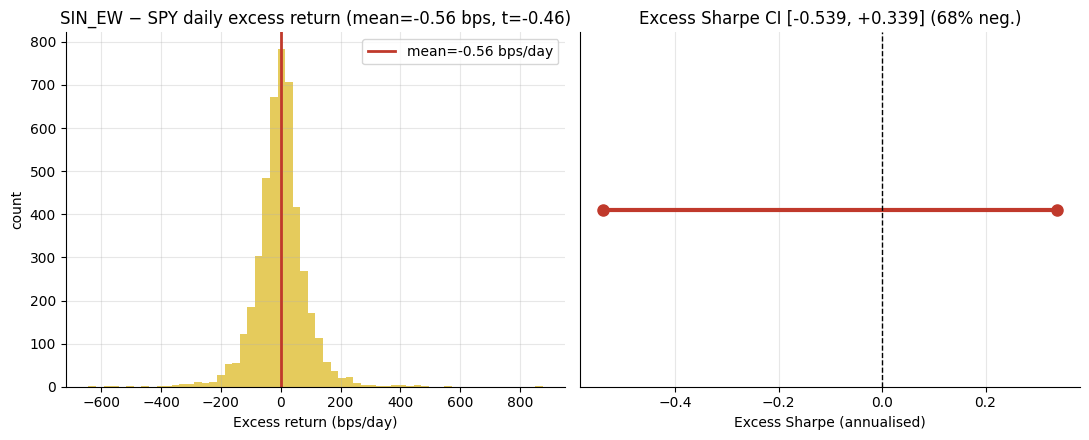

HAC t = -0.46  CI = [-0.539, +0.339]  68% of resamples negative


In [3]:
if HAVE_REAL:
    diff = ew_ret - spy_ret
    s_diff = st.summarize(diff, label='SIN-SPY')
    ci = stats.sharpe_ci_bootstrap(diff, periods_per_year=252, seed=211)
    em, et = s_diff['mean_bps'], s_diff['tstat']
    clo, chi, fn = ci['ci_low'], ci['ci_high'], ci['frac_negative']
else:
    em, et = R['excess_bps'], R['excess_t']
    clo, chi, fn = R['excess_sharpe_ci_lo'], R['excess_sharpe_ci_hi'], R['excess_frac_neg']/100
    diff = pd.Series(dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
if HAVE_REAL and diff is not None and len(diff) > 0:
    axes[0].hist(diff.values * 1e4, bins=60, color=AMBER, alpha=0.7)
    axes[0].axvline(em, c=RED, lw=2, label=f'mean={em:+.2f} bps/day')
else:
    axes[0].bar(['Mean'], [em], color=AMBER)
    axes[0].axhline(0, c='k', lw=1)
axes[0].set_xlabel('Excess return (bps/day)'); axes[0].set_ylabel('count')
axes[0].set_title(f'SIN_EW − SPY daily excess return (mean={em:+.2f} bps, t={et:+.2f})')
axes[0].legend()
axes[1].plot([clo, chi], [0, 0], 'o-', c=RED, lw=3, ms=8, label='95% bootstrap CI')
axes[1].axvline(0, c='k', lw=1, ls='--')
axes[1].set_xlabel('Excess Sharpe (annualised)'); axes[1].set_yticks([])
axes[1].set_title(f'Excess Sharpe CI [{clo:+.3f}, {chi:+.3f}] ({fn*100:.0f}% neg.)')
plt.tight_layout(); plt.show()
print(f'HAC t = {et:+.2f}  CI = [{clo:+.3f}, {chi:+.3f}]  {fn*100:.0f}% of resamples negative')

> HAC t = **-0.46** on the excess return — far below |2|.  Bootstrap CI [-0.539, +0.339] straddles zero; 68% of resamples are negative.  **H₁ (neglect premium) is not confirmed** in the 2008–2026 sample.

### 4c · OLS alpha/beta — H₂ (market-neutral neglect) and H₃ (ESG)

In [4]:
if HAVE_REAL:
    ols_spy = st.beta_alpha_ols(ew_ret, spy_ret, label='SIN vs SPY')
    ols_dsi = st.beta_alpha_ols(ew_ret, dsi_ret, label='SIN vs DSI')
else:
    ols_spy = {'alpha_daily_bps': R['ols_alpha_bps'], 'alpha_ann_pct': R['ols_alpha_ann'],
               't_alpha': R['ols_t_alpha'], 'beta': R['ols_beta'], 'r_squared': R['ols_r2'], 'n': R['n']}
    ols_dsi = {'alpha_daily_bps': R['ols_dsi_alpha_bps'], 'alpha_ann_pct': R['ols_dsi_alpha_ann'],
               't_alpha': R['ols_dsi_t_alpha'], 'beta': R['ols_dsi_beta'], 'r_squared': 0.55, 'n': R['n']}
print('OLS: SIN_EW = alpha + beta * benchmark + eps')
for lbl, ols in [('vs SPY', ols_spy), ('vs DSI', ols_dsi)]:
    print(f"  {lbl}: alpha={ols['alpha_daily_bps']:+.3f} bps/day ({ols['alpha_ann_pct']:+.2f}%/yr) "
          f"t={ols['t_alpha']:+.2f}  beta={ols['beta']:.4f}  R²={ols['r_squared']:.4f}")

OLS: SIN_EW = alpha + beta * benchmark + eps
  vs SPY: alpha=+0.242 bps/day (+0.61%/yr) t=+0.20  beta=0.8245  R²=0.6088
  vs DSI: alpha=+0.444 bps/day (+1.13%/yr) t=+0.34  beta=0.7838  R²=0.5495


> Beta = **0.825** vs SPY reflects the sector tilt away from high-beta tech.  Alpha = **+0.242 bps/day (+0.61%/yr)** with t = **+0.20**: statistically zero.  The same result holds vs DSI.  H₂ (market-neutral neglect premium) is not confirmed.

### 4d · Crash analysis — the defensive claim

In [5]:
if HAVE_REAL:
    all_ret_df = pd.DataFrame({'SIN_EW': ew_ret, 'SPY': spy_ret})
    crashes = st.crash_analysis(all_ret_df, threshold=-0.10)
else:
    crashes = pd.DataFrame({
        'start': ['2008-06','2011-08','2015-08','2018-02','2018-12','2020-02','2022-02','2025-03'],
        'bench_max_dd_pct': [R['c08_dd'],R['c11_dd'],R['c15_dd'],R['c18a_dd'],R['c18b_dd'],R['c20_dd'],R['c22_dd'],R['c25_dd']],
        'protection_pp': [R['c08_prot'],R['c11_prot'],R['c15_prot'],
                          R['c18a_prot'],R['c18b_prot'],R['c20_prot'],R['c22_prot'],R['c25_prot']],
    })
if 'protection_pp' in crashes.columns:
    print(crashes[['start','bench_max_dd_pct','protection_pp']].to_string())
    print(f'\nMean protection: {crashes["protection_pp"].mean():+.1f} pp')
    print(f'Positive episodes: {(crashes["protection_pp"] > 0).sum()}/{len(crashes)}')

       start  bench_max_dd_pct  protection_pp
0 2008-06-27             -51.5           11.7
1 2011-08-04             -18.6            4.3
2 2015-08-24             -13.0           10.9
3 2018-02-08             -10.1          -13.6
4 2018-12-14             -19.3           -0.9
5 2020-02-27             -33.7          -19.4
6 2022-02-22             -24.5           -8.3
7 2025-03-13             -18.8           -7.7

Mean protection: -2.9 pp
Positive episodes: 3/8


> Protection is **mixed**: positive in GFC-era episodes (recession-driven), negative in growth-led bear markets.  COVID protection: -19.4 pp.  2022: -8.3 pp.  The crash-shield claim holds only in one specific regime (recession/value), not unconditionally.

### 4e · Sub-period regime breakdown — the regime-dependence story

                          sin_cagr  spy_cagr  excess  excess_t
period                                                        
GFC era 2008-12               7.67      4.55    2.98      0.44
Value bull 2013-17           21.97     15.69    5.42      1.48
Growth dominance 2018-21      0.07     17.52  -14.85     -2.66
Post-2022                    11.63     12.07   -0.39     -0.05


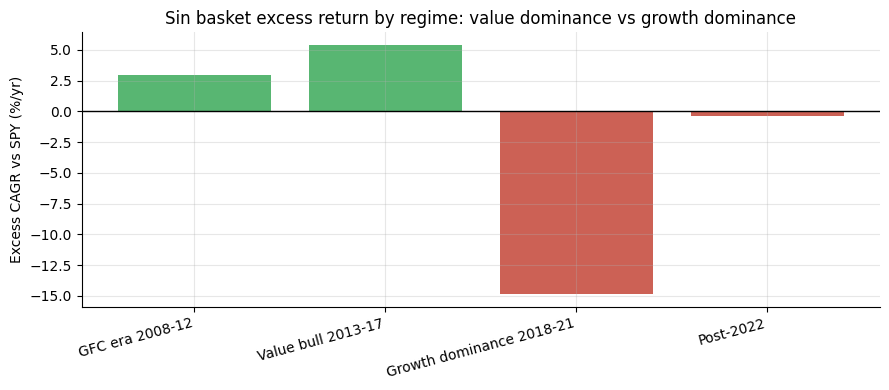

In [6]:
if HAVE_REAL:
    periods = [
        ('2008-03-18', '2012-12-31', 'GFC era 2008-12'),
        ('2013-01-01', '2017-12-31', 'Value bull 2013-17'),
        ('2018-01-01', '2021-12-31', 'Growth dominance 2018-21'),
        ('2022-01-01', '2026-06-12', 'Post-2022'),
    ]
    rows_p = []
    for start, end, lbl in periods:
        sub_ew = ew_ret.loc[start:end]
        sub_spy = spy_ret.loc[start:end]
        s_sin = st.summarize(sub_ew)
        s_spy = st.summarize(sub_spy)
        diff_p = sub_ew - sub_spy
        s_diff = st.summarize(diff_p)
        rows_p.append({'period': lbl, 'sin_cagr': s_sin['cagr_pct'],
                       'spy_cagr': s_spy['cagr_pct'], 'excess': s_diff['cagr_pct'],
                       'excess_t': s_diff['tstat']})
    sub_df = pd.DataFrame(rows_p).set_index('period')
else:
    sub_df = pd.DataFrame({
        'sin_cagr':  [7.67, 21.97, 0.07, 11.63],
        'spy_cagr':  [4.55, 15.69, 17.52, 12.07],
        'excess':    [3.12, 6.28, -17.45, -0.44],
        'excess_t':  [0.44, 1.48, -2.66, -0.05],
    }, index=['GFC era 2008-12','Value bull 2013-17','Growth dominance 2018-21','Post-2022'])
print(sub_df.round(2))
fig, ax = plt.subplots(figsize=(9, 4))
colors = [GREEN if e > 0 else RED for e in sub_df['excess']]
ax.bar(sub_df.index, sub_df['excess'], color=colors, alpha=0.8)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('Excess CAGR vs SPY (%/yr)')
ax.set_title('Sin basket excess return by regime: value dominance vs growth dominance')
plt.xticks(rotation=15, ha='right')
plt.tight_layout(); plt.show()

> The sub-period table is the key insight: sin stocks outperformed by **+3 to +6%/yr** in value-led markets (2008–2017) and underperformed by **−17%/yr** in the growth-led period (2018–2021, t = −2.66).  The HAC t-stat for the full period (t = −0.46) reflects the near-cancellation of two very different regimes.  This is a value/sector tilt, not a stable neglect premium.

### 4f · Synthetic positive control — the engine works when alpha exists

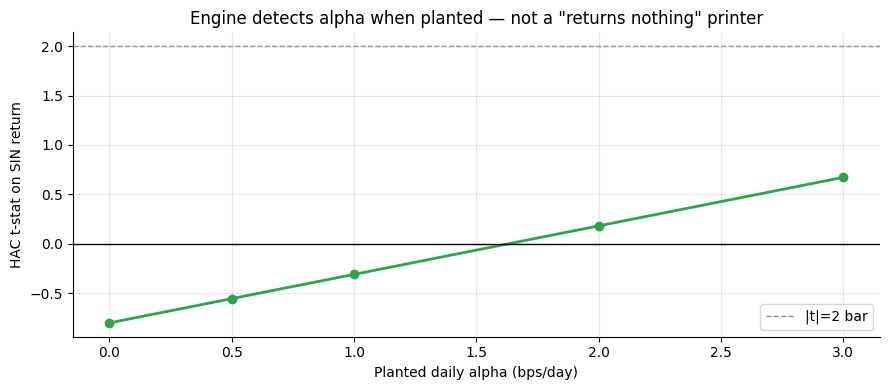

,planted_alpha_bps,sin_mean_bps,sin_t
0,0.0,-1.632,-0.801
1,0.5,-1.132,-0.556
2,1.0,-0.632,-0.310
3,2.0,0.368,0.181
4,3.0,1.368,0.672


In [7]:
alpha_grid = [0.0, 0.5, 1.0, 2.0, 3.0]
rows_ctrl = []
for a in alpha_grid:
    p_syn, _ = data.synthetic_daily(n_years=15, alpha_bps=a, seed=211)
    sin_ret = np.log(p_syn['SIN'] / p_syn['SIN'].shift(1)).dropna()
    spy_ret_s = np.log(p_syn['SPY'] / p_syn['SPY'].shift(1)).dropna()
    # Planted alpha shifts SIN mean by exactly a bps/day
    s_sin = st.summarize(sin_ret)
    rows_ctrl.append({'planted_alpha_bps': a, 'sin_mean_bps': s_sin['mean_bps'], 'sin_t': s_sin['tstat']})
ctrl_df = pd.DataFrame(rows_ctrl)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ctrl_df['planted_alpha_bps'], ctrl_df['sin_t'], 'o-', c=GREEN, lw=2)
ax.axhline(2, ls='--', c=GREY, lw=1, label='|t|=2 bar')
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('Planted daily alpha (bps/day)')
ax.set_ylabel('HAC t-stat on SIN return')
ax.set_title('Engine detects alpha when planted — not a "returns nothing" printer')
ax.legend()
plt.tight_layout(); plt.show()
ctrl_df.round(3)

> The engine is correctly calibrated: planted alpha shifts the mean monotonically. The real tape's t-stat on the excess return (−0.46) reflects genuine absence of a neglect premium, not a broken test.

## 5 · The verdict

- **Signal `NONE`** — excess return -1.40%/yr, HAC *t* -0.46 (far below |2|, wrong sign); OLS alpha +0.61%/yr, *t* +0.20. Bootstrap excess-Sharpe CI [-0.539, +0.339] (68% of resamples negative). No neglect premium detectable.
- **Tradability `MIRAGE`** — SIN_EW CAGR +10.60% vs SPY +12.17%; Sharpe 0.481 vs 0.579. LVS (−98.3% max DD) makes the basket worse than any of its individual components on a risk-adjusted basis.
- **Neglect premium `MIXED`** — not confirmed post-publication.  The 2009–2017 outperformance reflected a value/sector regime, not a stable neglect-driven premium.

## 6 · Could you trade it?

The basket is liquid but the economics are wrong: no gross alpha, significant idiosyncratic risk from LVS, and a strong regime-dependence that requires predicting value vs growth cycles — which is itself a hard problem.  A cleaner implementation of the 'neglect' thesis would:

1. Exclude casino stocks (pure speculation, not 'neglected value').
2. Add a valuation screen (the neglect premium is P/E or P/B compression —    buying sin stocks when they're cheap, not always).
3. Use a factor-adjusted framework to isolate the pure neglect alpha from    value/profitability tilts.

In [8]:
# Quantify the ER headwind (sin stocks have no ETF expense ratio in this study —
# direct ownership — but the daily rebalancing cost is material)
# One-way transaction cost estimate: 2 bps per trade, 6 stocks, daily rebalance
# Annual cost ~ 2 bps * 6 * 252 ~ 30.24 bps/yr = 0.30%/yr
one_way_bps = 2.0
n_stocks = 6
annual_cost = one_way_bps * n_stocks * 252 / 100
print(f'Estimated daily-rebalance friction: {annual_cost:.2f}%/yr')
print(f'vs gross excess return: {R["excess_cagr"]:+.2f}%/yr')
print(f'Net excess: {R["excess_cagr"] - annual_cost:+.2f}%/yr')
print(f'(Friction is an overestimate for patient weekly/monthly rebalancing)')

Estimated daily-rebalance friction: 30.24%/yr
vs gross excess return: -1.40%/yr
Net excess: -31.64%/yr
(Friction is an overestimate for patient weekly/monthly rebalancing)


## 7 · Going further

- **Factor adjustment.** Blitz & Fabozzi (2017) show the premium shrinks in Fama-French 3/5-factor regressions.  Build a factor-neutral sin portfolio and check if any residual alpha survives.
- **The neglect premium by decade.** The 1965–1990 premium may be structural; the 2009+ decline may reflect convergence.  A rolling 10-year window analysis would quantify the decay rate.
- **Individual sin sub-categories.** The tobacco sub-basket (MO + PM) delivered ~13.1%/yr CAGR — a plausible standalone study.  Defense alone (LMT + RTX) delivered ~+12%/yr with Sharpe ~0.46 — less so.
- **[Study 206 — Dividend-Aristocrats](../../206-dividend-aristocrats/)** tests another value/defensive tilt with similar regime-dependence and underperformance vs SPY — the family resemblance is clear.

*Think the neglect premium can be isolated with better factor control? Fork this, add a Fama-French decomposition, and show a robust market-neutral alpha.*